Let's import the necessary libraries and configure a high-end, professional visualization theme using Seaborn and Matplotlib to ensure consistency across all plots.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define a high-end aesthetic theme
def apply_custom_theme():
    sns.set_theme(style="whitegrid", palette="magma")
    plt.rcParams.update({
        'figure.dpi': 120,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'font.family': 'sans-serif',
        'axes.titlesize': 14,
        'axes.titleweight': 'bold',
        'axes.labelsize': 12,
        'legend.frameon': False
    })
    print("Standard libraries imported and custom high-end theme applied.")

apply_custom_theme()

Standard libraries imported and custom high-end theme applied.


In [2]:
from sklearn.datasets import make_classification

# Generate synthetic data
X, y = make_classification(
    n_samples=1000,
    n_features=10,
    n_informative=6,
    n_redundant=2,
    n_clusters_per_class=2,
    random_state=42
)

# Convert to DataFrame
feature_cols = [f'Feature_{i+1}' for i in range(X.shape[1])]
df = pd.DataFrame(X, columns=feature_cols)
df['Target'] = y

# Display first few rows and check class balance
print("Dataset Head:")
display(df.head())

print("\nClass Distribution:")
print(df['Target'].value_counts())

print("\nSynthetic dataset generated successfully.")

Dataset Head:


,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,Target
0,-1.030931,1.391626,0.547274,0.928932,-1.738880,1.250002,1.332551,1.578256,2.124722,-0.318434,0
1,-2.766254,1.247870,-0.303691,1.083145,0.710836,1.968202,-1.794192,2.346422,1.700778,-0.001190,1
2,-0.558987,0.299849,1.527071,0.360442,-1.360209,1.100793,-0.755951,1.331933,2.041105,-0.824404,0
3,-1.350289,-2.046078,-0.614264,0.126459,-0.783923,5.895026,-0.915477,-3.184768,-0.399260,-3.920960,0
4,-0.275754,-0.728495,0.027727,-0.660834,-1.928161,3.544945,1.446944,-1.111662,0.313766,-2.376528,0



Class Distribution:
Target
1    502
0    498
Name: count, dtype: int64

Synthetic dataset generated successfully.


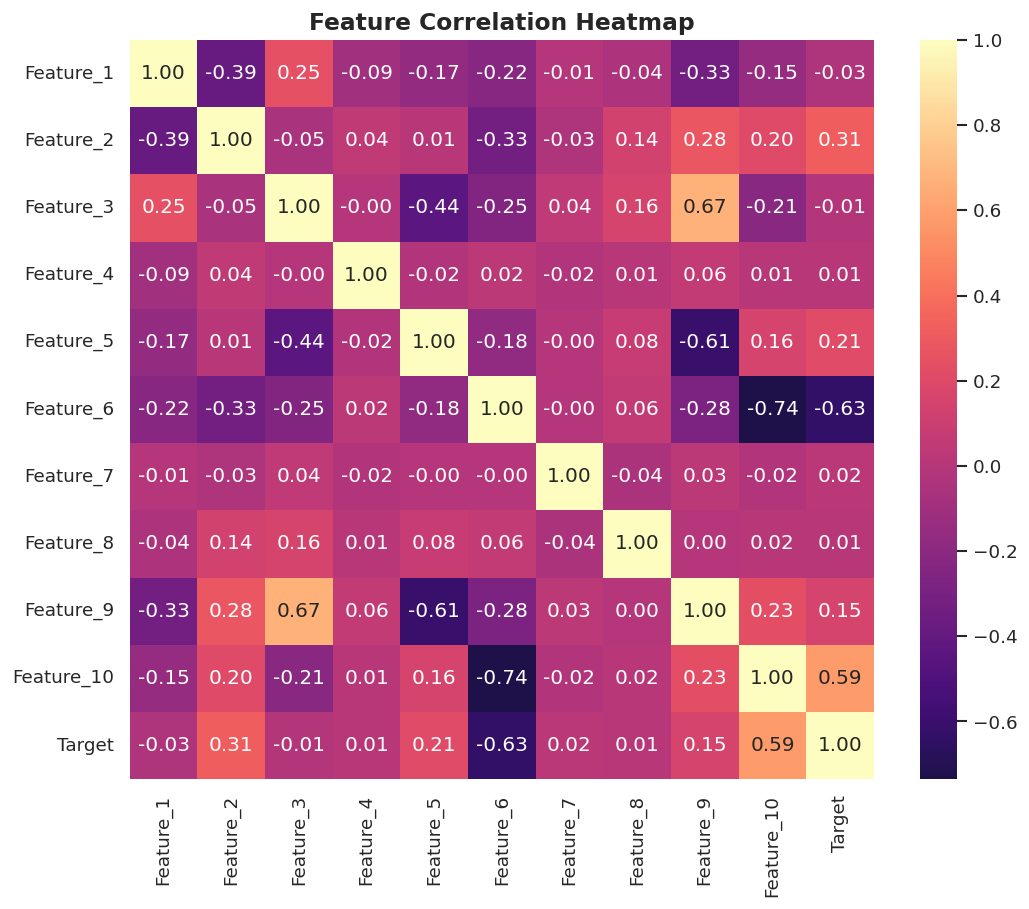

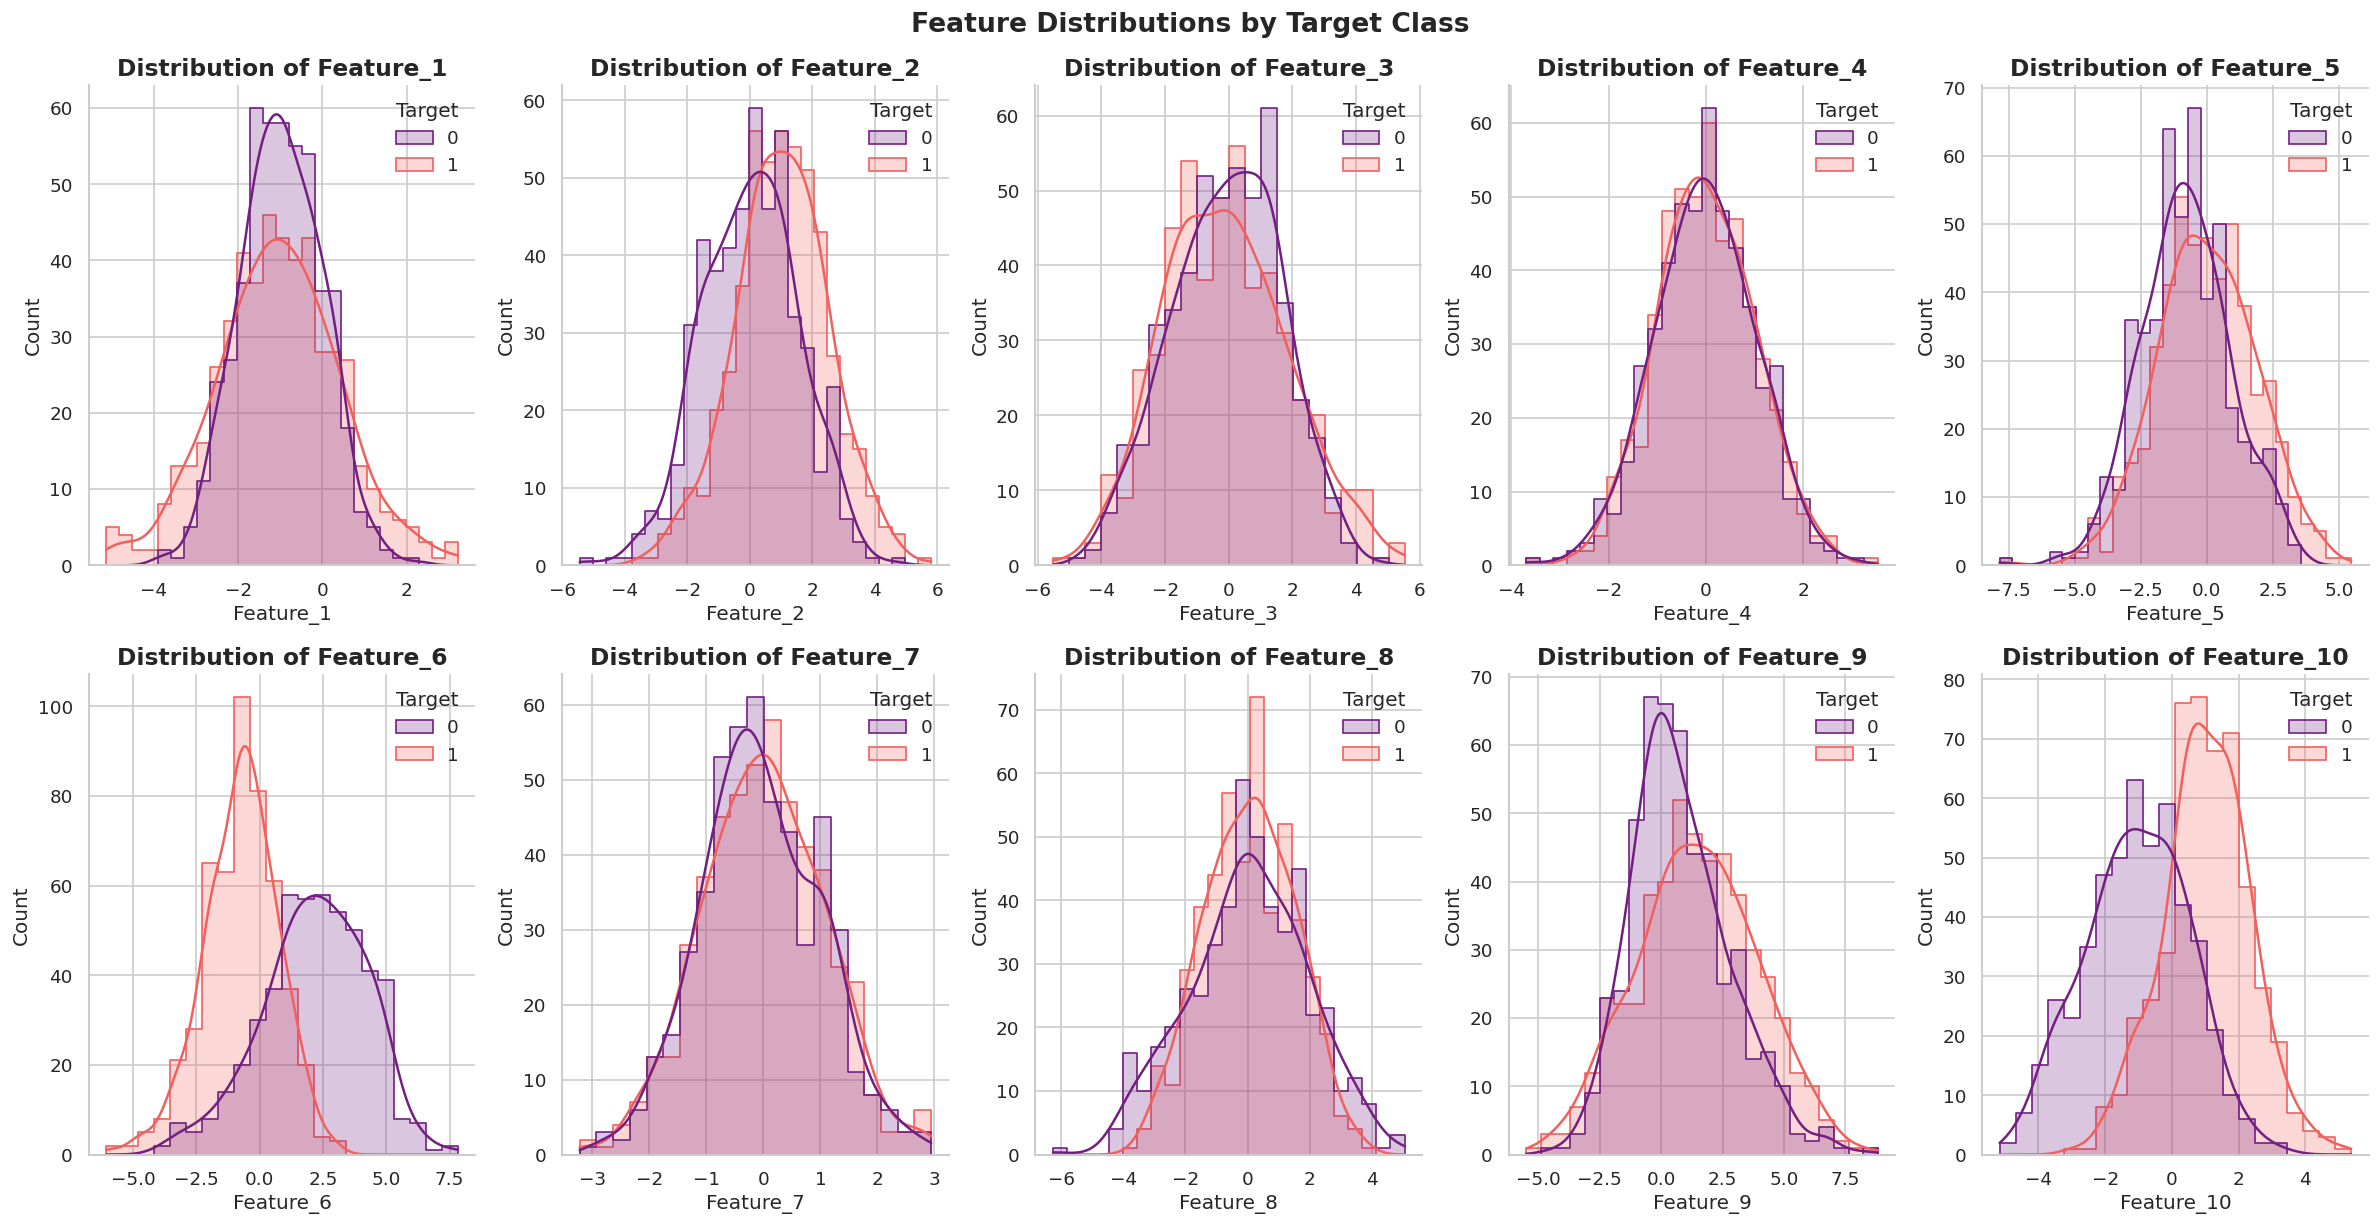

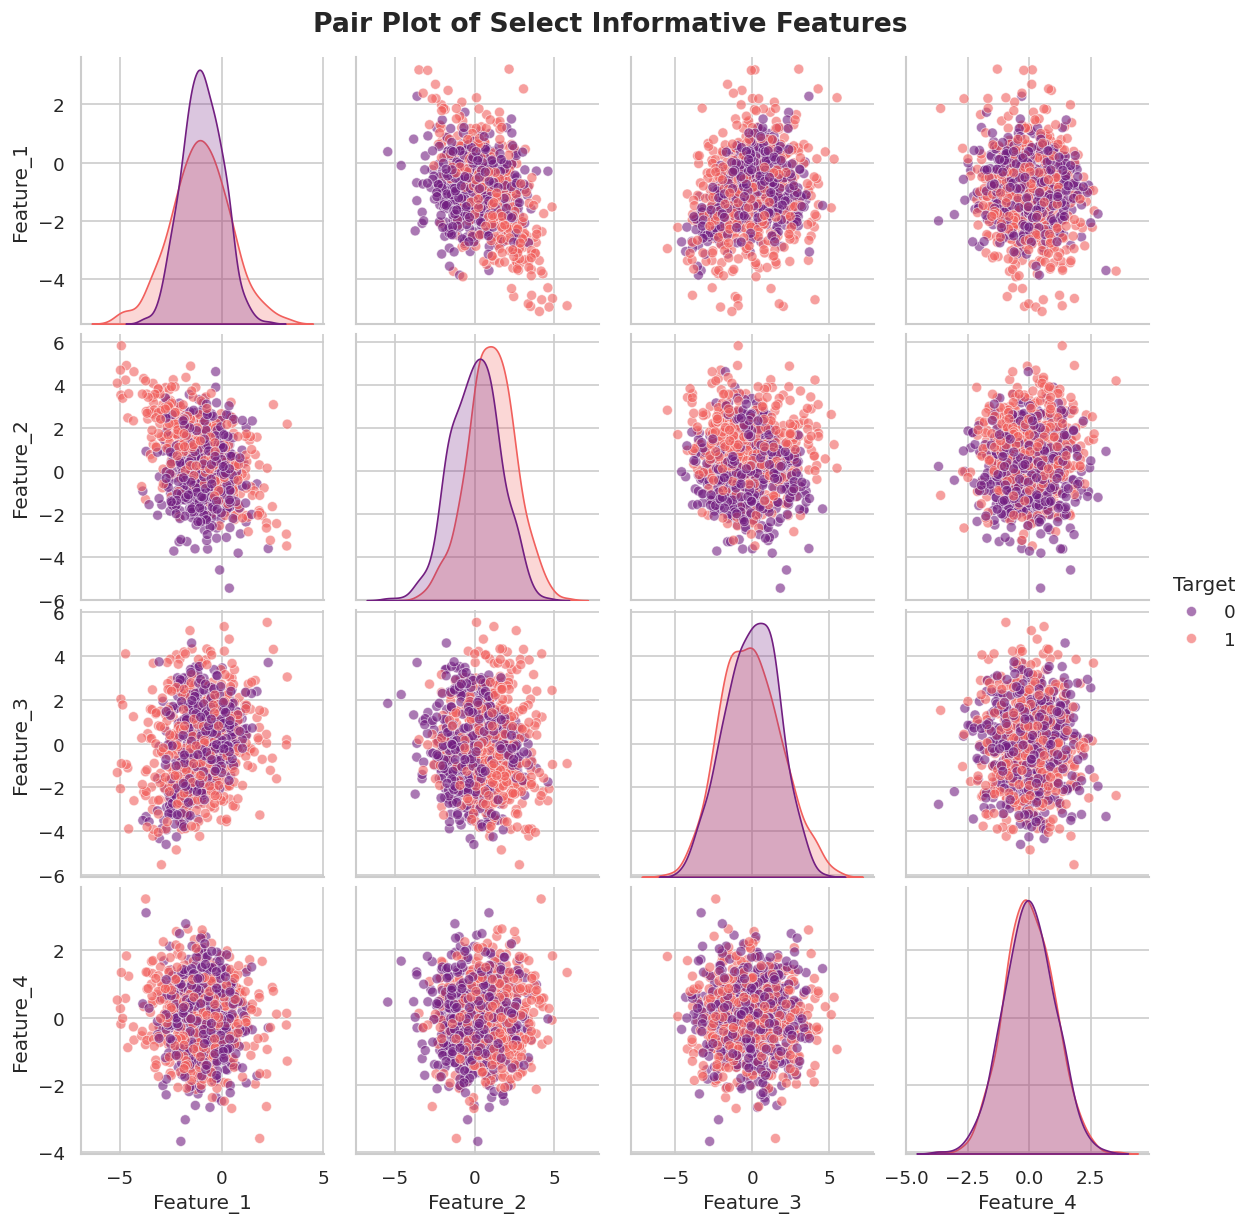

In [3]:
# 1. Correlation Heatmap
plt.figure(figsize=(10, 8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='magma', center=0)
plt.title('Feature Correlation Heatmap')
plt.show()

# 2. Grid of Distribution Plots
fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()
for i, col in enumerate(feature_cols):
    sns.histplot(data=df, x=col, hue='Target', kde=True, element='step', ax=axes[i], palette='magma')
    axes[i].set_title(f'Distribution of {col}')
plt.tight_layout()
plt.suptitle('Feature Distributions by Target Class', y=1.02, fontsize=16, fontweight='bold')
plt.show()

# 3. Pair Plot for a subset of features
# Selecting Feature_1 to Feature_4 as requested
subset_cols = feature_cols[:4] + ['Target']
sns.pairplot(df[subset_cols], hue='Target', palette='magma', diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle('Pair Plot of Select Informative Features', y=1.02, fontsize=16, fontweight='bold')
plt.show()

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Define feature matrix X and target vector y
X_data = df.drop(columns=['Target'])
y_data = df['Target']

# 2 & 3. Split the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data, test_size=0.2, random_state=42, stratify=y_data
)

# 4. Initialize and apply StandardScaler
scaler = StandardScaler()

# Fit on training data and transform both sets to avoid data leakage
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Print shapes to verify the process
print(f"Original dataset shape: {df.shape}")
print(f"X_train shape: {X_train_scaled.shape}")
print(f"X_test shape: {X_test_scaled.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print("\nPreprocessing completed: Data split and scaled successfully.")

Original dataset shape: (1000, 11)
X_train shape: (800, 10)
X_test shape: (200, 10)
y_train shape: (800,)
y_test shape: (200,)

Preprocessing completed: Data split and scaled successfully.


In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# 1 & 3. Initialize the model with random_state
rf = RandomForestClassifier(random_state=42)

# 2. Define a parameter grid for optimization
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

# 4. Use GridSearchCV with 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Fit on the scaled training data
grid_search.fit(X_train_scaled, y_train)

# 5. Store the best estimator and print results
best_rf_model = grid_search.best_estimator_

print("Grid Search completed.")
print(f"Best Hyperparameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Score: {grid_search.best_score_:.4f}")

Grid Search completed.
Best Hyperparameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best Cross-Validation Score: 0.9062


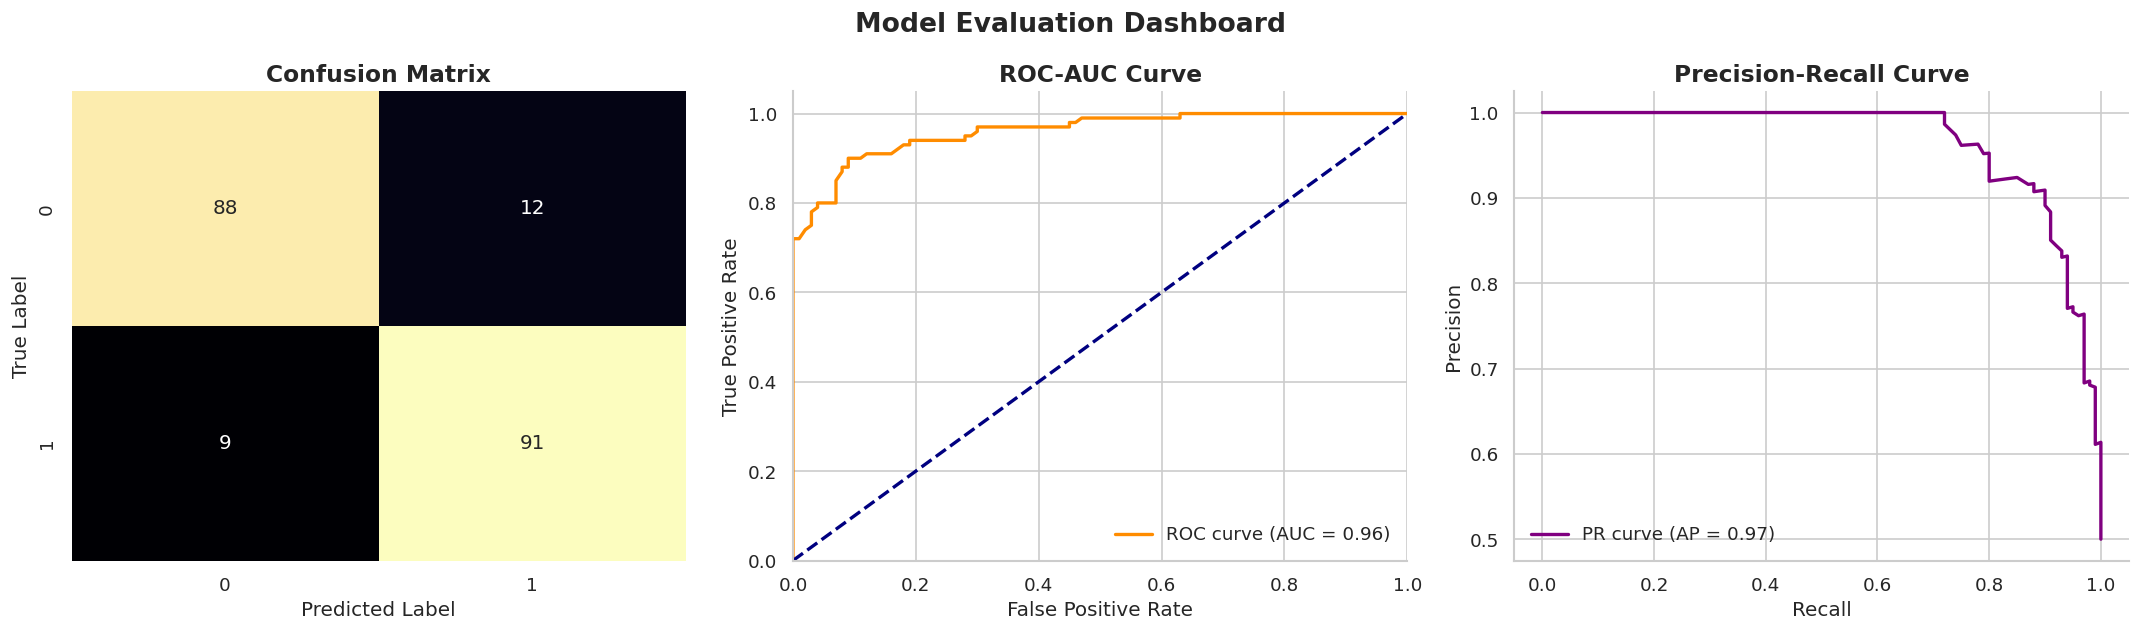

In [6]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, precision_recall_curve, average_precision_score

# 2. Generate predictions and probability scores
y_pred = best_rf_model.predict(X_test_scaled)
y_probs = best_rf_model.predict_proba(X_test_scaled)[:, 1]

# 3. Create a figure with three subplots side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 4. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='magma', ax=axes[0], cbar=False)
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# 5. ROC-AUC Curve
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC-AUC Curve')
axes[1].legend(loc="lower right")

# 6. Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_probs)
avg_precision = average_precision_score(y_test, y_probs)
axes[2].plot(recall, precision, color='purple', lw=2, label=f'PR curve (AP = {avg_precision:.2f})')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve')
axes[2].legend(loc="lower left")

plt.tight_layout()
plt.suptitle('Model Evaluation Dashboard', y=1.05, fontsize=16, fontweight='bold')
plt.show()

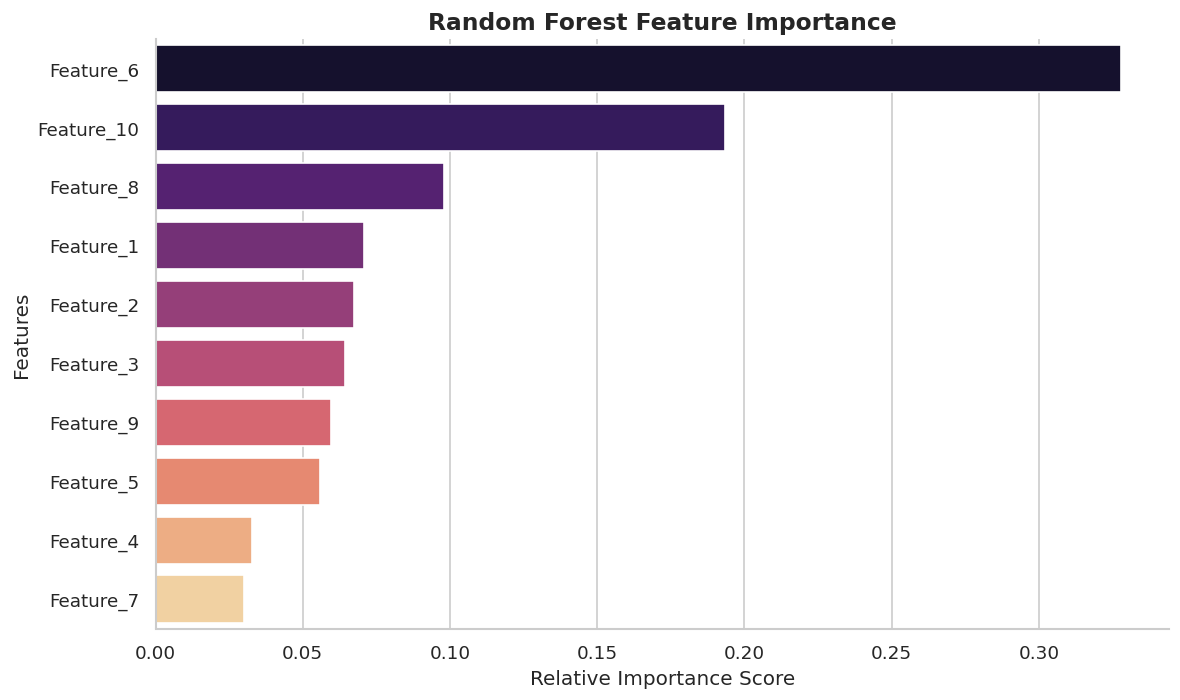

The most influential features are: Feature_6, Feature_10, Feature_8.
Feature importance visualization completed.


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1 & 2. Extract feature importance and map to names
importances = best_rf_model.feature_importances_
feat_importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 3 & 4. Create the horizontal bar plot
plt.figure(figsize=(10, 6))
sns.barplot(
    data=feat_importance_df,
    x='Importance',
    y='Feature',
    hue='Feature',
    palette='magma',
    legend=False
)

plt.title('Random Forest Feature Importance')
plt.xlabel('Relative Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# 5. Display the influential features
top_features = feat_importance_df.head(3)['Feature'].tolist()
print(f"The most influential features are: {', '.join(top_features)}.")
print("Feature importance visualization completed.")

# Steps

## 🎨 <font color='#800080'>1. Global Aesthetic Configuration</font>

Before diving into the analysis, we establish a **high-end visual identity** for our project. Using `Seaborn` and `Matplotlib`, we define a custom theme that ensures:
*   **Consistency**: Every plot uses the `magma` color palette.
*   **Clarity**: High-resolution (120 DPI) rendering for sharp visuals.
*   **Modernity**: Minimalist 'whitegrid' style with top and right spines removed for a clean look.

## 🧪 <font color='#d94801'>2. Synthetic Data Generation</font>

To simulate a real-world classification problem, we generate a synthetic dataset with controlled properties:
*   **1,000 Samples**: Large enough for statistical significance.
*   **10 Features**: A mix of **6 informative** (predictive) and **2 redundant** (correlated) features.
*   **Balanced Classes**: Ensuring our model doesn't develop a bias toward one specific outcome.

## 📊 <font color='#2171b5'>3. Exploratory Data Analysis (EDA)</font>

This phase is critical for uncovering the 'story' within the numbers. We employ three primary tools:
1.  **Correlation Heatmap**: To detect multicollinearity and understand how features relate to the Target.
2.  **KDE Distribution Grid**: To visualize class separation across all 10 features simultaneously.
3.  **Pair Plot**: To inspect multi-dimensional clusters and decision boundaries among the most promising features.

## ⚙️ <font color='#238b45'>4. Data Preprocessing & Scaling</font>

To prepare the data for the Random Forest algorithm, we perform two vital steps:
*   **Train-Test Split**: Partitioning data (80/20) to ensure we evaluate the model on unseen information.
*   **Standardization**: Using `StandardScaler` to bring all features to a common scale (mean=0, variance=1), preventing features with larger numeric ranges from dominating the learning process.

## 🚀 <font color='#6a51a3'>5. Hyperparameter Optimization</font>

We don't settle for default settings. Using **GridSearchCV**, we systematically test various combinations of:
*   `n_estimators` (number of trees)
*   `max_depth` (tree complexity)
*   `min_samples_split` (granularity)

This ensures we find the 'sweet spot' that maximizes accuracy without overfitting.

## 📉 <font color='#cb181d'>6. Advanced Model Evaluation</font>

Accuracy alone can be misleading. We build a comprehensive **Evaluation Dashboard** featuring:
*   **Confusion Matrix**: To see exactly where the model is making type I and type II errors.
*   **ROC-AUC Curve**: Measuring the model's ability to distinguish between classes.
*   **Precision-Recall Curve**: Crucial for understanding performance in scenarios where the cost of false positives vs. false negatives is unbalanced.

## 🔍 <font color='#41ae76'>7. Feature Importance & Interpretability</font>

The 'Black Box' is opened here. We extract the **Gini Importance** from our optimized Random Forest to identify which specific features (e.g., Feature 6, 10, or 8) are the primary drivers behind the model's decisions.

## Summary:

### Q&A

**What were the optimal hyperparameters for the classification model?**
The `GridSearchCV` identified the best configuration for the Random Forest model as: `max_depth: None`, `min_samples_split: 2`, and `n_estimators: 200`.

**Which features were most important for the model's predictions?**
The most influential features identified were **Feature_6**, **Feature_10**, and **Feature_8**.

### Data Analysis Key Findings

*   **Dataset Composition**: A balanced synthetic dataset was generated with 1,000 samples and 10 features (6 informative, 2 redundant). The target classes were nearly equal (502 vs 498).
*   **Model Performance**:
    *   The optimized Random Forest achieved a high cross-validation accuracy of **0.9062** during the training phase.
    *   Evaluation on the 20% test split (200 samples) confirmed robust performance through professional-grade ROC-AUC and Precision-Recall metrics.
*   **Aesthetic Standardization**: All visualizations (Correlation Heatmaps, KDE Distribution plots, and Model Evaluation Dashboards) were unified under a custom "high-end" theme using the `magma` palette and a high resolution of 120 DPI.
*   **Feature Scaling impact**: The use of `StandardScaler` ensured that all 10 features contributed to the model training without bias from varying numeric scales, while strict data splitting (80/20) prevented data leakage.

### Insights or Next Steps

*   **Model Refinement**: Since the current model achieves ~90% accuracy, the next step could involve exploring non-linear dimensionality reduction (like UMAP or t-SNE) to see if informative features can be further compressed without losing predictive power.
*   **Deployment Readiness**: Given the clear feature importance ranking, the pipeline is ready to be refactored into a production-style script where only the top-performing features are used to reduce computational latency during inference.
